# Solution-Vector Amplitudes & Segment Angles (fixed ε = 2 mrad, γ = 3)

Two views of the **individual segments**, split by truth, read from the stored
solution vectors (events + geometry regenerated on demand — nothing re-solved):

1. **Solution amplitudes** — the distribution of the solver output value
   `s_i` for true vs false segments (classical and quantum).  A healthy solver
   keeps the true peak above and the false peak below the activation threshold
   τ = δ/(δ+γ) + 0.10 (= 0.35 at γ = 3).
2. **Segment angles** — counts of true vs false segments against the per-segment
   polar angle θ (mrad) from the beam axis.  True (on-track) segments are
   collimated inside the generation cone; cross-track false segments spread to
   large θ.

The angle distribution is a property of the event geometry (same for both
solvers); the amplitude distribution is solver-specific (the quantum solution is
rescaled to the matching classical L2 norm before thresholding).

In [1]:
import sys
sys.path.insert(0, "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_level_studies")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seg_store as S

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                      "axes.grid": True, "grid.alpha": 0.3})
print("fixed acceptance ε =", S.EPS_FIXED, "rad (2 mrad)")
print("thresholds:  γ=1 -> τ=%.3f   γ=2 -> τ=%.3f   γ=3 -> τ=%.3f"
      % (S.threshold(1), S.threshold(2), S.threshold(3)))

OUT = Path(S.__file__).resolve().parent / "outputs" / "solution_amplitudes_and_angles"
OUT.mkdir(parents=True, exist_ok=True)
GAMMA = 3.0
CI = S.solves_index("classical")          # partner frame for quantum rescale
print("classical solves:", len(CI), " quantum solves:", len(S.solves_index("quantum")))

fixed acceptance ε = 0.002 rad (2 mrad)
thresholds:  γ=1 -> τ=0.600   γ=2 -> τ=0.433   γ=3 -> τ=0.350


classical solves: 960  quantum solves: 109


In [2]:
def pool(solver, gamma, hit_ineff, n_trk, max_reps=5):
    """Pool true/false solution values and segment angles over a few reps."""
    idx = S.solves_index(solver, gamma, hit_ineff)
    idx = idx[idx.n_trk == n_trk].head(max_reps)
    st, sf, tt, tf, tau = [], [], [], [], None
    for _, r in idx.iterrows():
        v = S.load_vectors(r, classical_partner=CI if solver == "quantum" else None)
        m, sol, th = v["truth"], v["sol"], v["theta_mrad"]
        st.append(sol[m]); sf.append(sol[~m]); tt.append(th[m]); tf.append(th[~m])
        tau = v["tau"]
    if not st:
        return None
    return dict(sol_true=np.concatenate(st), sol_false=np.concatenate(sf),
                th_true=np.concatenate(tt), th_false=np.concatenate(tf),
                tau=tau, n_used=len(idx))

N_GRID = [10, 100, 400, 1000]
REPS_AMP = {10: 5, 100: 5, 400: 3, 1000: 2}

## Solution amplitudes — true vs false segments

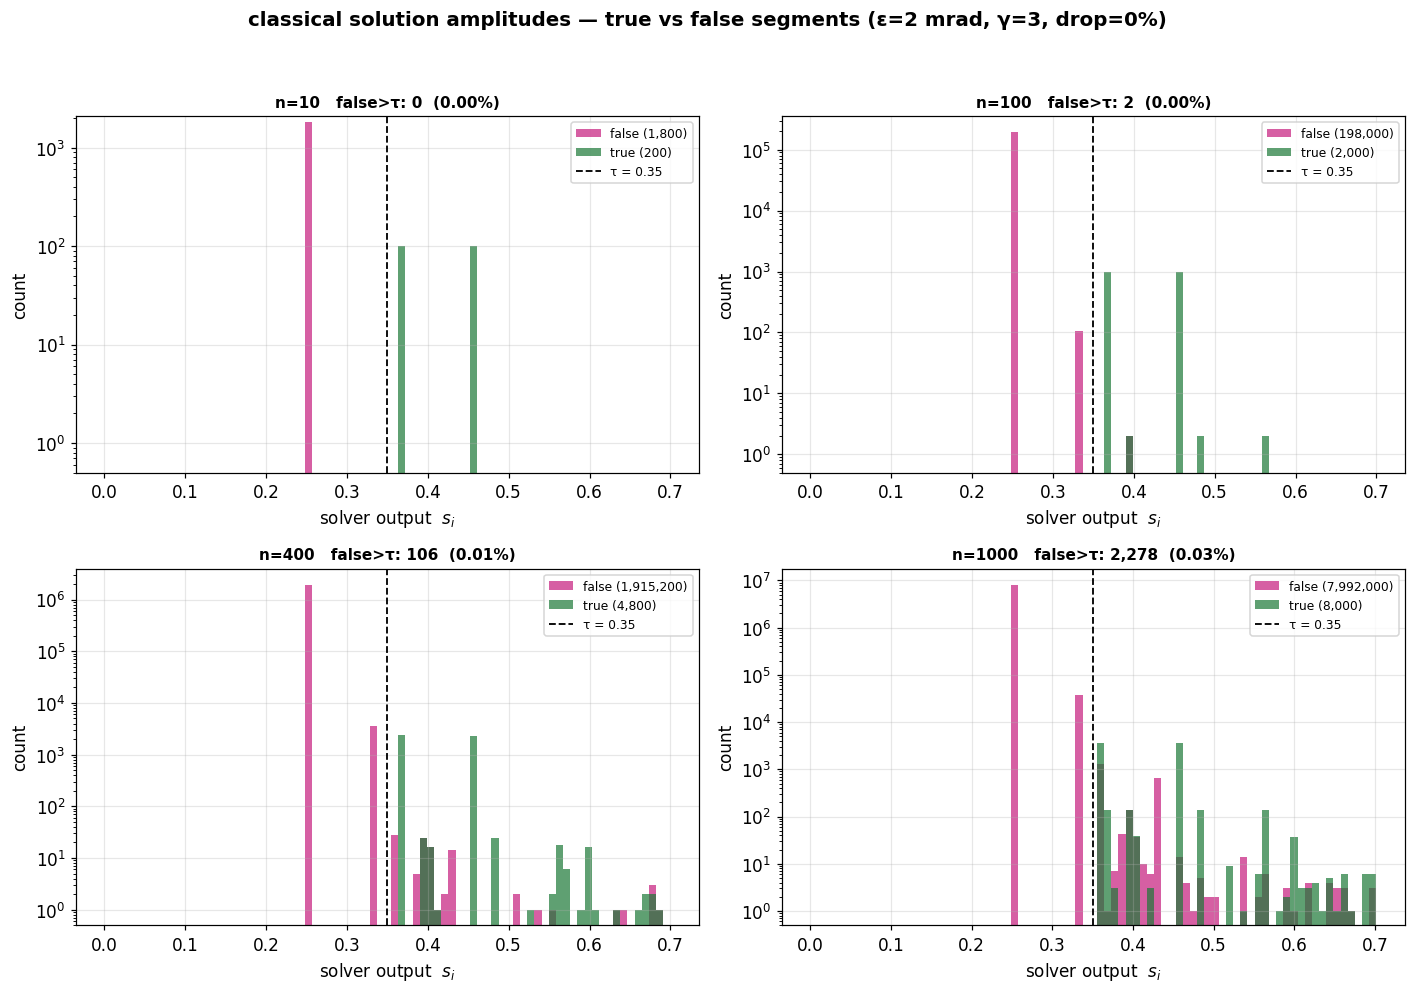

saved classical_amplitudes_g3


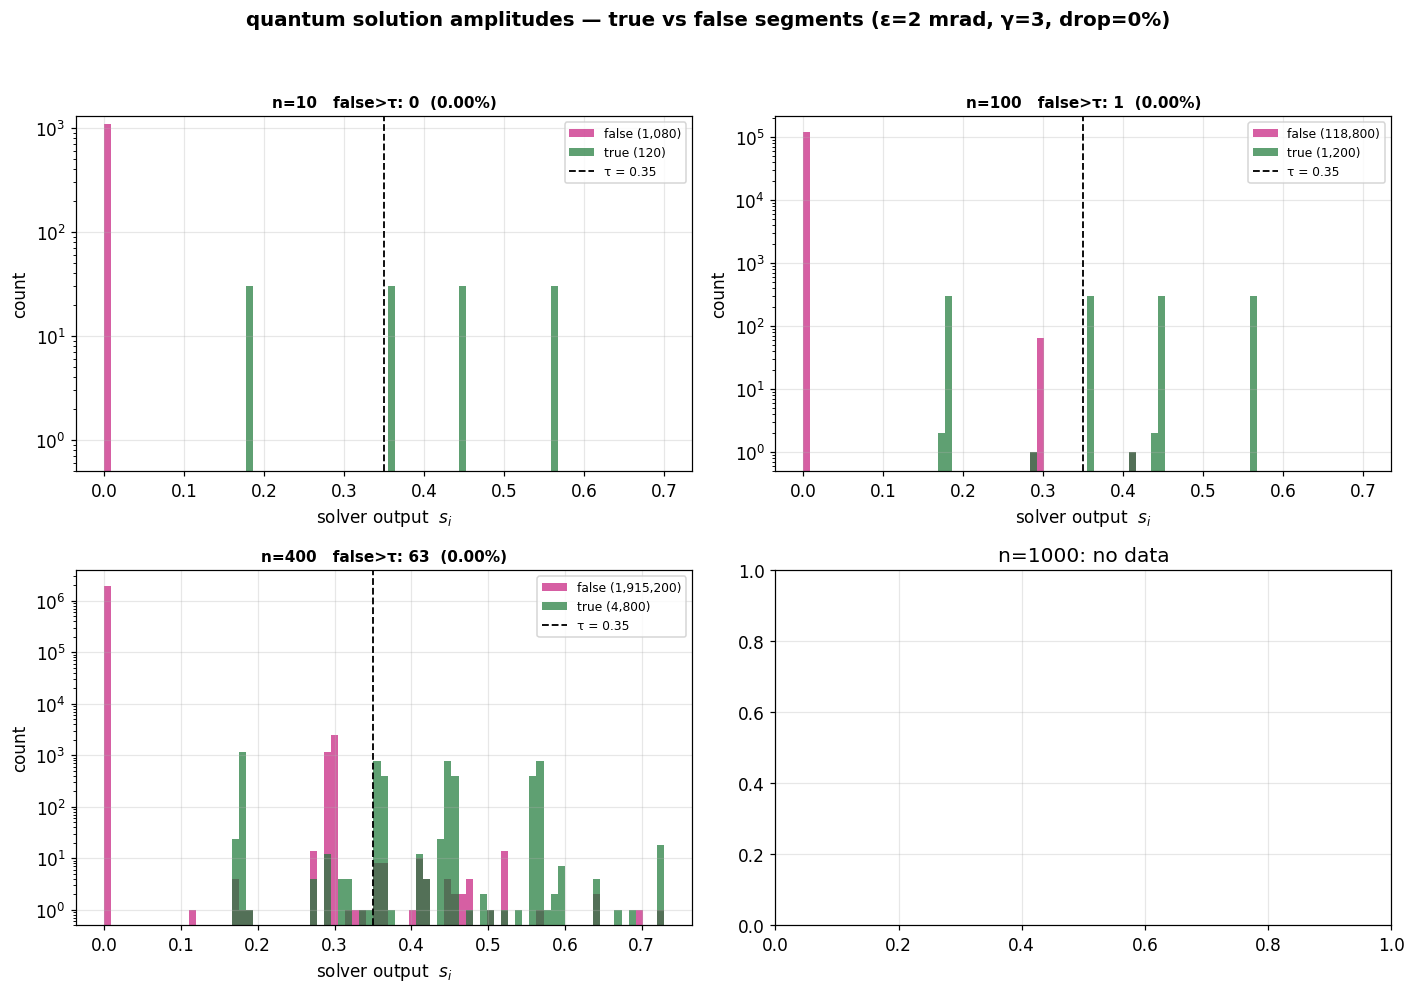

saved quantum_amplitudes_g3


In [3]:
def amp_figure(solver, hit_ineff=0.0, stem=None):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, n in zip(axes.ravel(), N_GRID):
        p = pool(solver, GAMMA, hit_ineff, n, max_reps=REPS_AMP[n])
        if p is None:
            ax.set_title(f"n={n}: no data"); continue
        hi = max(np.percentile(p["sol_true"], 99.5) if len(p["sol_true"]) else 1.0,
                 p["tau"] * 2)
        bins = np.linspace(min(0.0, p["sol_false"].min()), hi, 80)
        ax.hist(p["sol_false"], bins=bins, color="#c51b7d", alpha=0.7,
                label=f"false ({len(p['sol_false']):,})")
        ax.hist(p["sol_true"], bins=bins, color="#1b7837", alpha=0.7,
                label=f"true ({len(p['sol_true']):,})")
        ax.axvline(p["tau"], color="k", ls="--", lw=1.2, label=f"τ = {p['tau']:.2f}")
        fp = int((p["sol_false"] > p["tau"]).sum())
        ax.set_title(f"n={n}   false>τ: {fp:,}  ({fp/max(len(p['sol_false']),1)*100:.2f}%)",
                     fontsize=10, fontweight="bold")
        ax.set_yscale("log"); ax.set_ylim(0.5, None)
        ax.set_xlabel("solver output  $s_i$"); ax.set_ylabel("count")
        ax.legend(fontsize=8, loc="upper right")
    fig.suptitle(f"{solver} solution amplitudes — true vs false segments "
                 f"(ε=2 mrad, γ=3, drop={hit_ineff*100:.0f}%)",
                 fontsize=13, fontweight="bold", y=1.00)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    stem = stem or f"{solver}_amplitudes"
    for ext, dpi in (("pdf", 600), ("png", 300)):
        fig.savefig(OUT / f"{stem}.{ext}", dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.show(); print("saved", stem)

amp_figure("classical", hit_ineff=0.0, stem="classical_amplitudes_g3")
amp_figure("quantum",   hit_ineff=0.0, stem="quantum_amplitudes_g3")

## Segment angles — true vs false (counts vs θ)

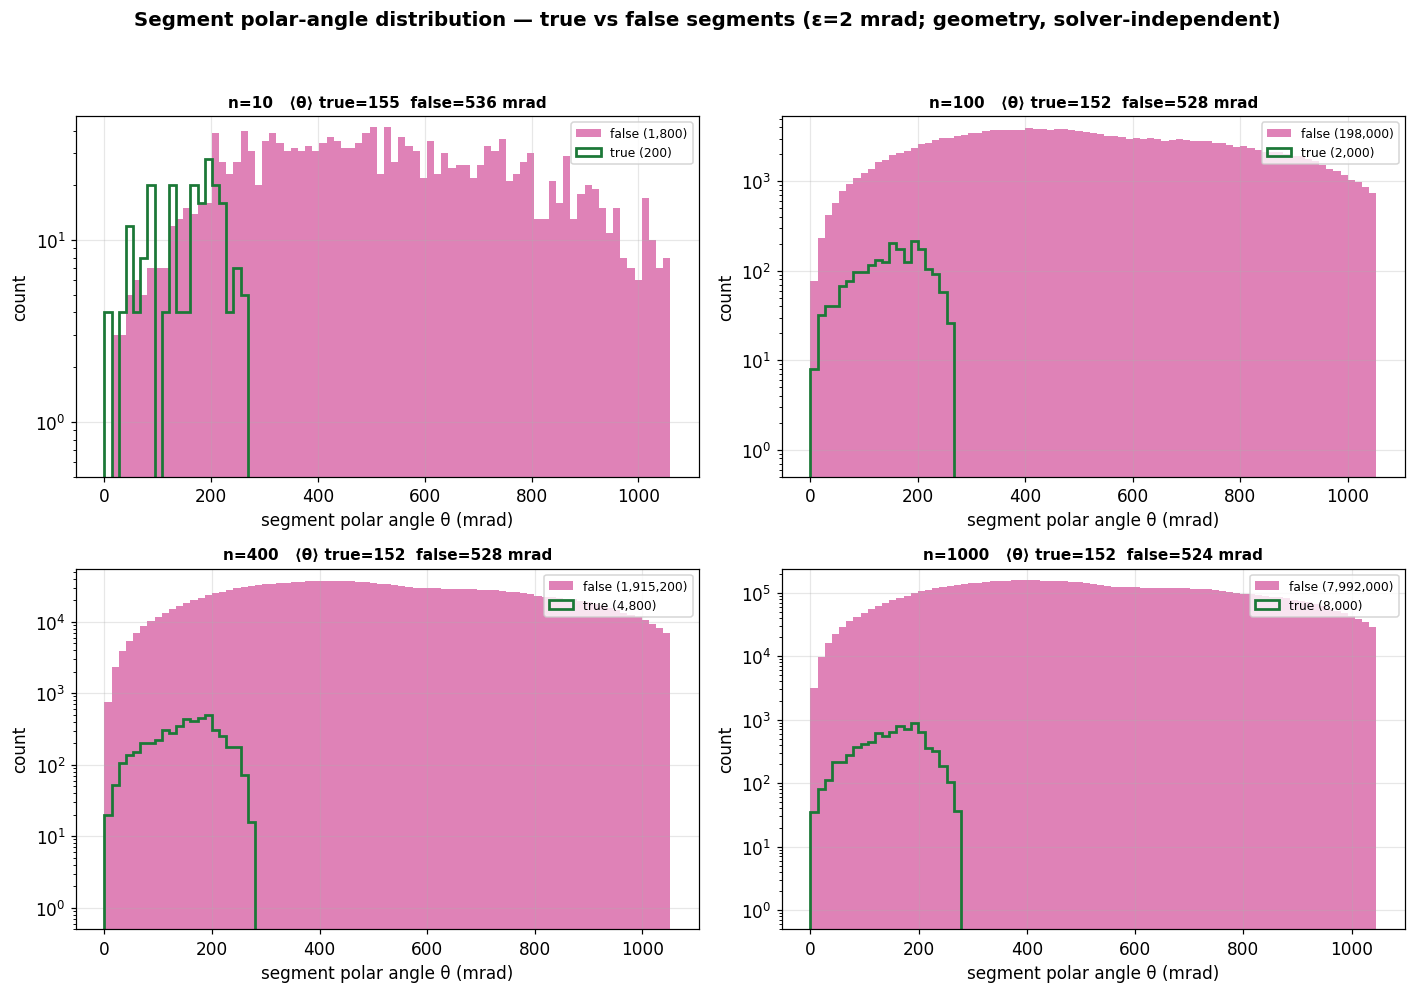

saved segment_angles_truefalse_g3


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, n in zip(axes.ravel(), N_GRID):
    p = pool("classical", GAMMA, 0.0, n, max_reps=REPS_AMP[n])  # geometry only
    if p is None:
        ax.set_title(f"n={n}: no data"); continue
    hi = np.percentile(p["th_false"], 99) if len(p["th_false"]) else 500
    bins = np.linspace(0, hi, 80)
    # false (the overwhelming majority) as a fill; true as a bold outline on top
    # so the rarer on-track segments stay visible.  Log count keeps both legible.
    ax.hist(p["th_false"], bins=bins, color="#c51b7d", alpha=0.55,
            label=f"false ({len(p['th_false']):,})")
    ax.hist(p["th_true"], bins=bins, histtype="step", color="#1b7837", lw=1.8,
            label=f"true ({len(p['th_true']):,})")
    ax.set_yscale("log"); ax.set_ylim(0.5, None)
    ax.set_title(f"n={n}   "
                 f"⟨θ⟩ true={np.mean(p['th_true']):.0f}  false={np.mean(p['th_false']):.0f} mrad",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("segment polar angle θ (mrad)"); ax.set_ylabel("count")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Segment polar-angle distribution — true vs false segments "
             "(ε=2 mrad; geometry, solver-independent)",
             fontsize=13, fontweight="bold", y=1.00)
fig.tight_layout(rect=[0, 0, 1, 0.97])
for ext, dpi in (("pdf", 600), ("png", 300)):
    fig.savefig(OUT / f"segment_angles_truefalse_g3.{ext}", dpi=dpi,
                bbox_inches="tight", facecolor="white")
plt.show(); print("saved segment_angles_truefalse_g3")